# Smart License Plate Expiration Detection — Demo Notebook
**Group 05 / LC01 — Computer Vision Final Project**

Pipeline (exactly the methods selected in the proposal):

`image → grayscale + Gaussian → Canny + contours → HOG → SVM (plate?) → char segmentation → HOG + SVM (OCR) → expiry vs current date`

This notebook runs **self-contained on synthetic plates** so it executes anywhere.
Sections marked **▶ REAL DATA** show how to switch to the Kaggle dataset
(`caasperart/haarcascadeplatenumber`) for your final results.

In [1]:
import os, sys, random
sys.path.insert(0, os.path.abspath('..'))   # repo root on path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from src.preprocessing import preprocess, to_grayscale
from src.plate_detection import find_candidates, canny_edges, draw_boxes
from src.features import plate_hog, char_hog, hog_visualization, normalize_char
from src.plate_classifier import PlateClassifier
from src.char_segmentation import segment_characters, split_rows, _binarise
from src.ocr import OCRClassifier, build_synthetic_dataset
from src.expiry import check_expiry
from src.pipeline import LicensePlateExpiryPipeline
from src import evaluation as ev
from src.synthetic import make_plate, make_scene, random_plate_text
from config import SUCCESS_CRITERIA

random.seed(0); np.random.seed(0)
def show(img, title='', cmap=None, sz=(6,4)):
    plt.figure(figsize=sz)
    if img.ndim==3: img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img, cmap=cmap); plt.title(title); plt.axis('off'); plt.show()

## 1. Build a sample scene
A synthetic Indonesian-style plate composited on a noisy background.

Ground truth plate: AB6048SN | expiry: 05.27 | box: (133, 56, 313, 123)


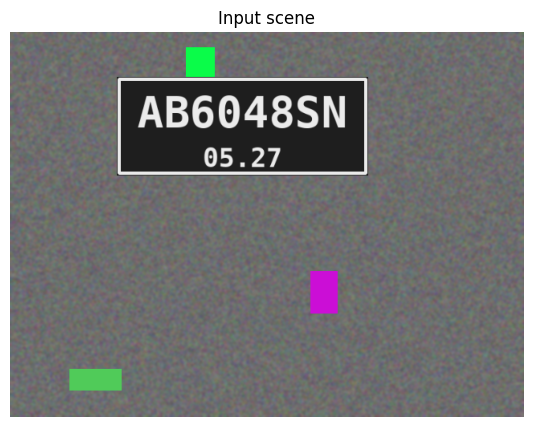

In [2]:
num, exp, truth = random_plate_text()
plate = make_plate(num, exp, dark=True)
scene, gt_box = make_scene(plate, seed=7)
print('Ground truth plate:', truth, '| expiry:', exp, '| box:', gt_box)
show(scene, 'Input scene', sz=(7,5))

## 2. Preprocessing — grayscale + Gaussian filter

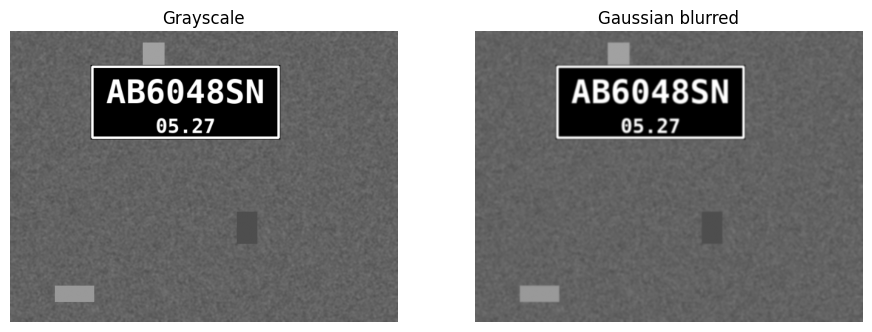

In [3]:
gray = preprocess(scene)
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].imshow(to_grayscale(scene), cmap='gray'); ax[0].set_title('Grayscale'); ax[0].axis('off')
ax[1].imshow(gray, cmap='gray'); ax[1].set_title('Gaussian blurred'); ax[1].axis('off')
plt.show()

## 3. Canny edge detection + contour candidates

4 plate-like candidates found


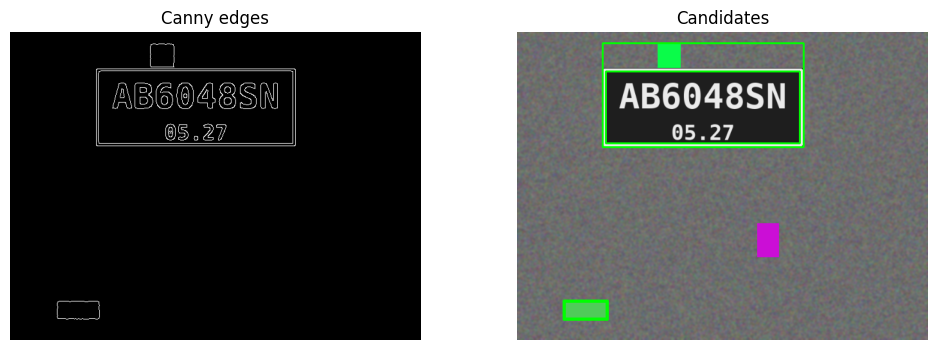

In [4]:
edges = canny_edges(gray)
cands = find_candidates(gray)
boxes = [c.box for c in cands]
print(f'{len(cands)} plate-like candidates found')
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].imshow(edges, cmap='gray'); ax[0].set_title('Canny edges'); ax[0].axis('off')
vis = draw_boxes(scene, boxes, (0,255,0))
ax[1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); ax[1].set_title('Candidates'); ax[1].axis('off')
plt.show()

## 4. HOG features
The descriptor that feeds both SVMs. Below: HOG of the true plate region.

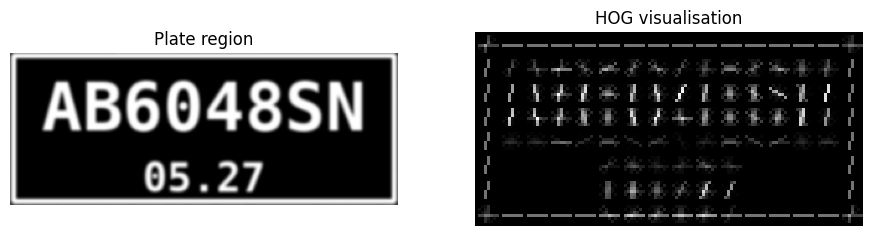

HOG vector length (plate): 3780


In [5]:
x,y,w,h = gt_box
plate_crop = gray[y:y+h, x:x+w]
hog_img = hog_visualization(plate_crop)
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].imshow(plate_crop, cmap='gray'); ax[0].set_title('Plate region'); ax[0].axis('off')
ax[1].imshow(hog_img, cmap='gray'); ax[1].set_title('HOG visualisation'); ax[1].axis('off')
plt.show()
print('HOG vector length (plate):', plate_hog(plate_crop).shape[0])

## 5. Train the SVM plate classifier
Synthetic positives (plate crops) vs negatives (random background crops).

**▶ REAL DATA:** run `scripts/prepare_dataset.py` then `scripts/train_plate_svm.py`,
and load with `PlateClassifier.load()` instead of training here.

In [6]:
pos, neg = [], []
for i in range(60):
    n, e, _ = random_plate_text()
    p = make_plate(n, e, dark=random.random()<0.5)
    sc, (bx,by,bw,bh) = make_scene(p, seed=1000+i)
    g = preprocess(sc)
    pos.append(g[by:by+bh, bx:bx+bw])
    for _ in range(2):
        rw, rh = random.randint(40,120), random.randint(20,70)
        rx, ry = random.randint(0, sc.shape[1]-rw-1), random.randint(0, sc.shape[0]-rh-1)
        neg.append(g[ry:ry+rh, rx:rx+rw])

X = np.vstack([plate_hog(c) for c in pos+neg])
yv = np.array([1]*len(pos) + [0]*len(neg))
plate_clf = PlateClassifier().fit(X, yv)
print(f'Trained plate SVM on {len(pos)} positives / {len(neg)} negatives')

Trained plate SVM on 60 positives / 120 negatives


## 6. Character segmentation
Binarise the plate, find character-sized contours, sort into rows.

13 characters | top row=9 bottom row=4


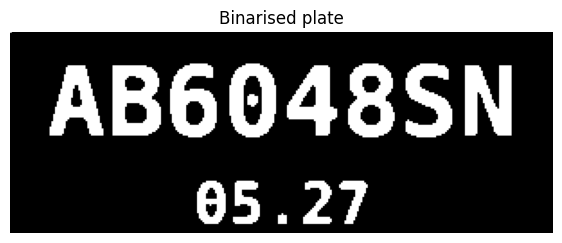

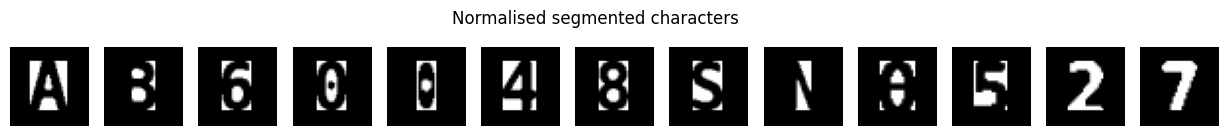

In [7]:
best = plate_clf.select_plate(cands)
crop = best.crop if best is not None else plate_crop
chars = segment_characters(crop)
top, bottom = split_rows(chars, crop.shape[0])
print(f'{len(chars)} characters | top row={len(top)} bottom row={len(bottom)}')
show(_binarise(crop), 'Binarised plate', cmap='gray', sz=(7,3))
if chars:
    fig, ax = plt.subplots(1, len(chars), figsize=(1.2*len(chars), 1.6))
    for a, ch in zip(np.atleast_1d(ax), chars):
        a.imshow(normalize_char(ch.image), cmap='gray'); a.axis('off')
    plt.suptitle('Normalised segmented characters'); plt.show()

## 7. Train the SVM OCR classifier (0-9, A-Z)
Bootstrapped from font-rendered glyphs.

**▶ REAL DATA:** use a labelled character set with
`scripts/train_ocr_svm.py --source folders --char-dir PATH` for higher accuracy.

In [8]:
imgs, labels = build_synthetic_dataset(samples_per_class=200)
ocr = OCRClassifier().fit(imgs, labels)
print(f'Trained OCR SVM on {len(imgs)} character samples')

Trained OCR SVM on 7200 character samples


## 8. Full pipeline on the sample

success     : True
plate number: A46Q018SN (truth AB6048SN)
expiry      : '1527' -> UNKNOWN
reason      : Could not parse a valid MM/YY expiry from the plate.
timings (s) : {'preprocess': 0.0005, 'detection': 0.0031, 'classification': 0.0104, 'segmentation': 0.0006, 'ocr': 0.0533}


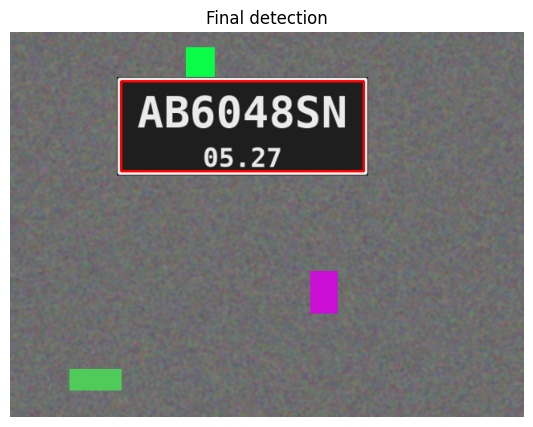

In [9]:
pipe = LicensePlateExpiryPipeline(plate_clf, ocr)
res = pipe.run(scene)
print('success     :', res.success)
print('plate number:', res.plate_number, '(truth', truth + ')')
if res.expiry:
    e = res.expiry
    status = 'UNKNOWN' if e.is_expired is None else ('EXPIRED' if e.is_expired else 'VALID')
    print(f'expiry      : {e.raw_text!r} -> {status}')
    print('reason      :', e.reason)
print('timings (s) :', {k: round(v,4) for k,v in res.timings.items()})
if res.plate_box:
    show(draw_boxes(scene, [res.plate_box], (0,0,255)), 'Final detection', sz=(7,5))

## 9. Evaluation against the proposal's success criteria
Run the whole pipeline over a synthetic test set and compute every metric.

In [10]:
pred_boxes, gt_boxes, scores = [], [], []
ocr_preds, ocr_truth = [], []
plate_y_true, plate_y_pred = [], []
processed_ok = 0
N = 40
for i in range(5000, 5000+N):
    n, e, t = random_plate_text()
    p = make_plate(n, e, dark=random.random()<0.5)
    sc, gt = make_scene(p, seed=i)
    r = pipe.run(sc)
    gt_boxes.append(gt); pred_boxes.append(r.plate_box)
    scores.append(1.0 if r.success else 0.0)
    plate_y_true.append(1)
    plate_y_pred.append(1 if (r.plate_box and ev.iou(r.plate_box, gt) >= 0.5) else 0)
    if r.success:
        processed_ok += 1
        ocr_preds.append(r.plate_number); ocr_truth.append(t)

cls = ev.classification_metrics(plate_y_true, plate_y_pred, positive=1)
metrics = {
    'accuracy':  cls.accuracy,
    'precision': cls.precision,
    'recall':    cls.recall,
    'f1':        cls.f1,
    'iou':       ev.mean_iou(pred_boxes, gt_boxes),
    'map':       ev.average_precision(pred_boxes, scores, gt_boxes),
    'char_accuracy': ev.character_accuracy(ocr_preds, ocr_truth) if ocr_preds else 0.0,
    'word_accuracy': ev.word_accuracy(ocr_preds, ocr_truth) if ocr_preds else 0.0,
    'wer':           ev.word_error_rate(ocr_preds, ocr_truth) if ocr_preds else 1.0,
    'end_to_end':    processed_ok / N,
}
print(ev.report(metrics, SUCCESS_CRITERIA))

Metric               Value    Target    Status
----------------------------------------------
accuracy             1.000      0.85      PASS
precision            1.000      0.85      PASS
recall               1.000      0.85      PASS
f1                   1.000      0.80      PASS
iou                  0.959      0.70      PASS
map                  0.909      0.90      PASS
char_accuracy        0.725      0.90      FAIL
word_accuracy        0.025      0.75      FAIL
wer                  0.275      0.15      FAIL
end_to_end           1.000      0.75      PASS


## 10. Notes & next steps

- **Numbers above are on *synthetic* data** for a runnable demo. Train on the
  Kaggle dataset for your reported results.
- **OCR** is the hardest stage with classical HOG + SVM. For higher character
  accuracy, train on a real labelled character set (Chars74K, or characters
  cropped from your plates) via `scripts/train_ocr_svm.py --source folders`.
- The expiry logic assumes the Indonesian **MM.YY** validity printed on the
  plate; adjust `src/expiry.py` if your plates use a different format.
- Everything maps to the proposal: Canny (localisation), HOG (features),
  SVM (plate classification **and** OCR), and the confusion-matrix /
  IoU / mAP / OCR metrics in the Evaluation section.